# Exploratory Data Analysis
Project STAR-derived dataset — predicting kindergarten reading and math scores.

**Targets:** `score_read`, `score_math`  
**Features:** student demographics, teacher attributes, school/class context

This notebook covers:
1. Data loading
2. Missing value analysis
3. Outlier detection
4. Univariate distributions
5. Bivariate plots (scores vs key covariates)
6. Birth-quarter cohort analysis
7. Correlation heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# Data Loading
df = pd.read_csv('sample_kinder_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (5060, 14)


,score_read,score_math,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
0,474.0,602.0,male,1980 Q2,free,cauc,small,rural,master,level1,6.0,cauc,36.0,72.0
1,403.0,434.0,male,1980 Q3,free,afam,small,rural,bachelor,apprentice,1.0,cauc,24.0,57.0
2,455.0,520.0,male,1980 Q2,non-free,cauc,regular+aide,suburban,bachelor,level1,5.0,afam,22.0,51.0
3,405.0,454.0,female,1979 Q4,free,cauc,regular+aide,rural,bachelor,level1,11.0,cauc,4.0,6.0
4,433.0,473.0,female,1980 Q3,non-free,cauc,regular,rural,bachelor,level1,2.0,cauc,40.0,76.0


## 1. Missing Values

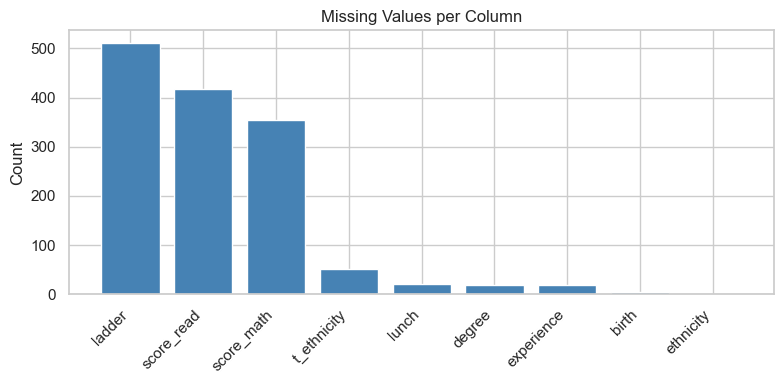

In [2]:
missing = df.isna().sum().to_frame('missing_count')
missing['pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing.index, missing['missing_count'], color='steelblue')
ax.set_title('Missing Values per Column')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Outlier Detection (IQR)

In [3]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'column': col, 'outliers': n_out, 'pct': round(n_out/len(df)*100, 2)})

pd.DataFrame(outlier_summary)

,column,outliers,pct
0,score_read,114,2.25
1,score_math,166,3.28
2,experience,31,0.61
3,schooldistrict_id,0,0.00
4,school_id,0,0.00


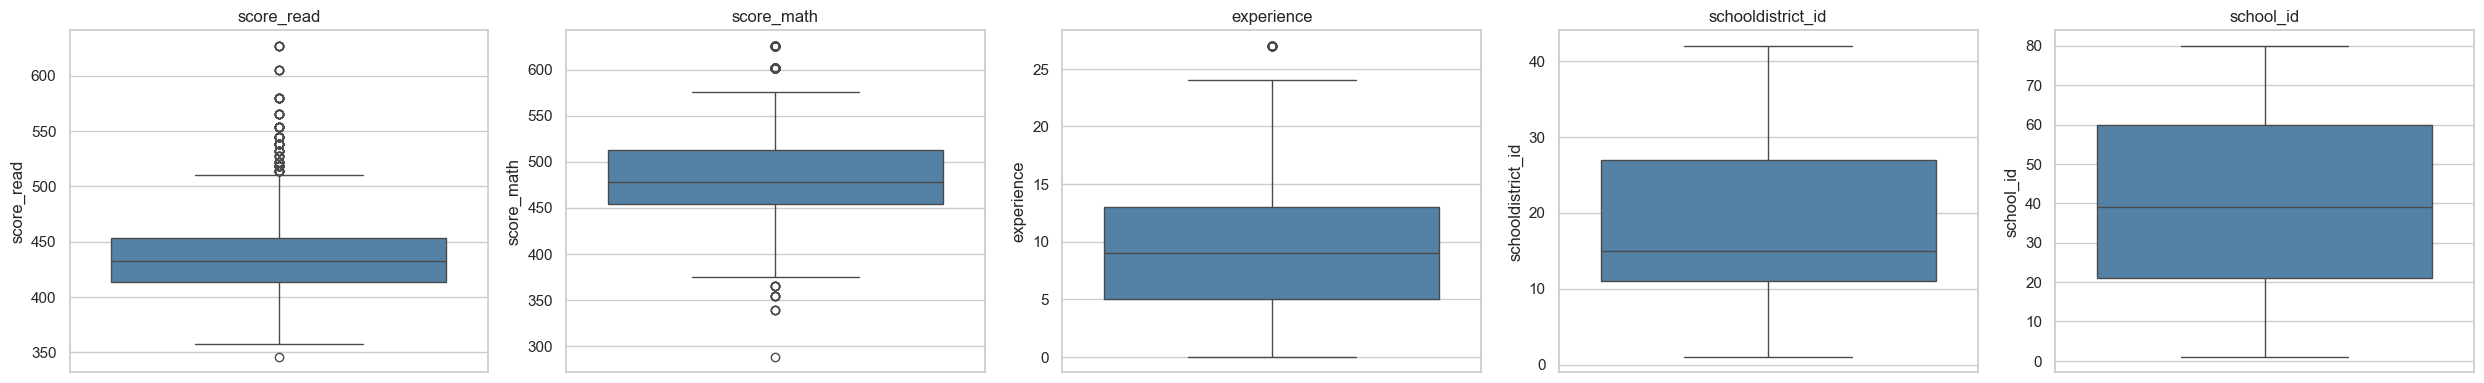

In [4]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Univariate Distributions

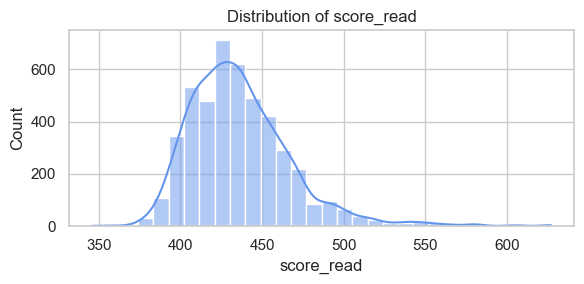

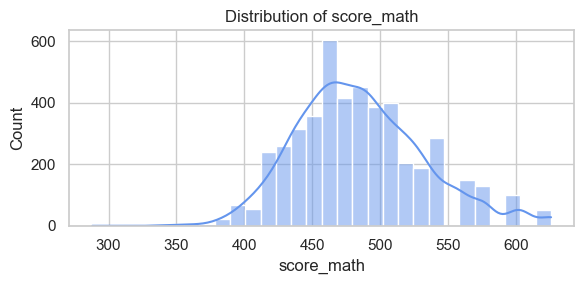

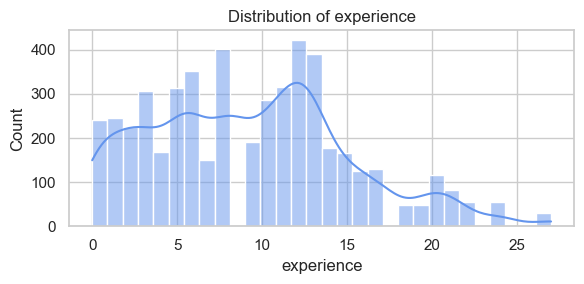

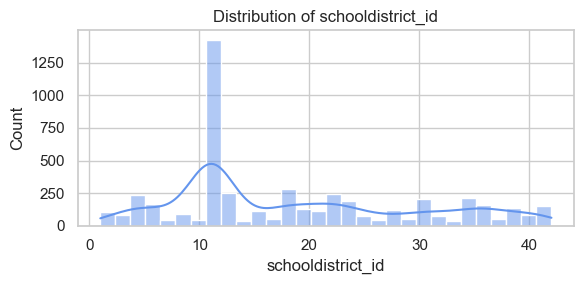

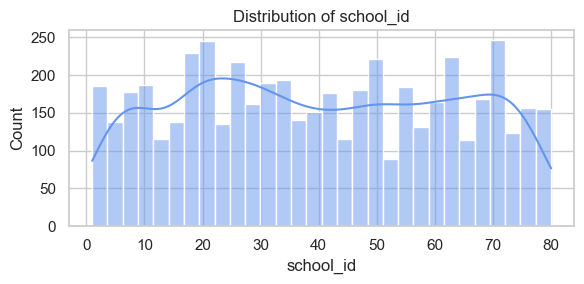

In [5]:
for col in num_cols:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='cornflowerblue', ax=ax)
    ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## 4. Bivariate: Scores vs Key Covariates

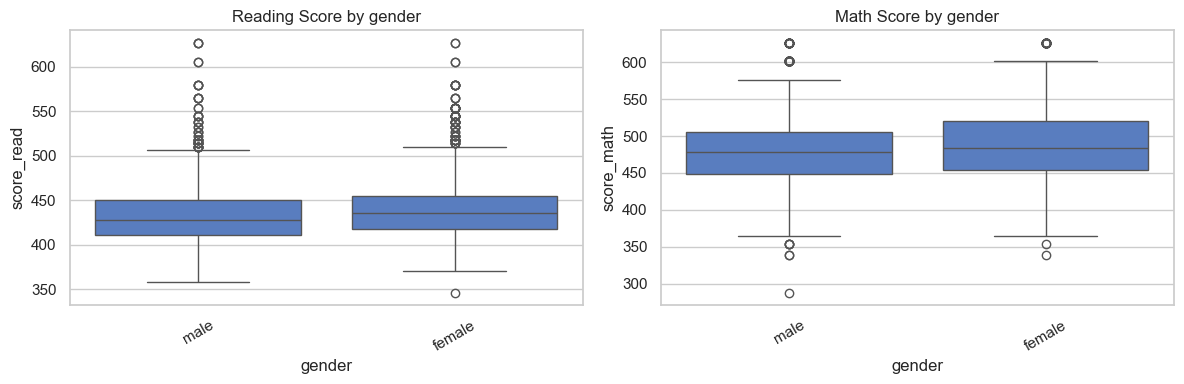

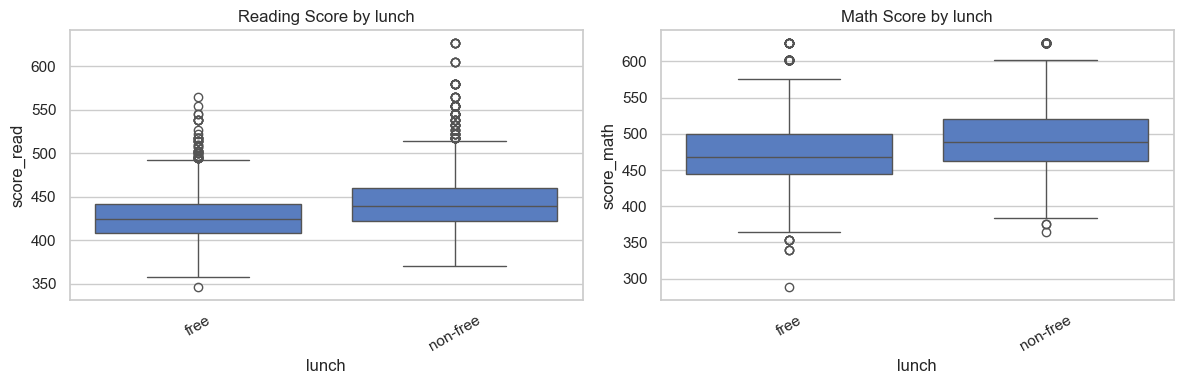

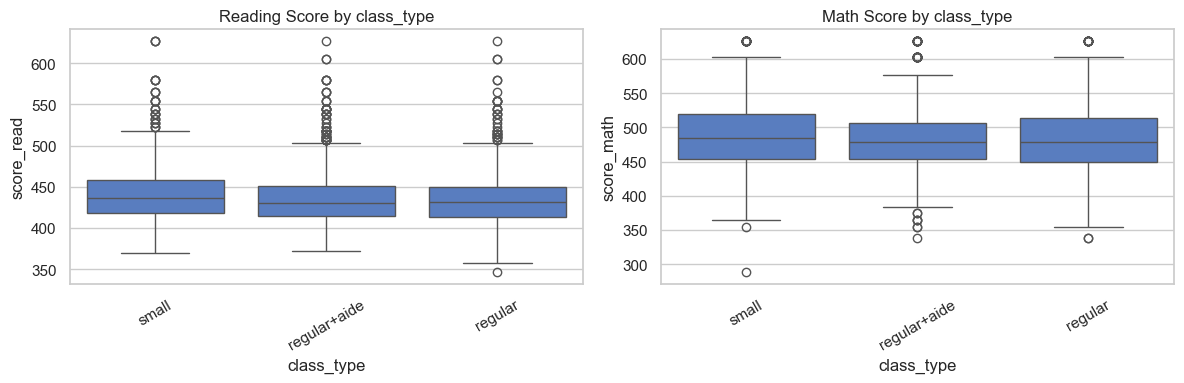

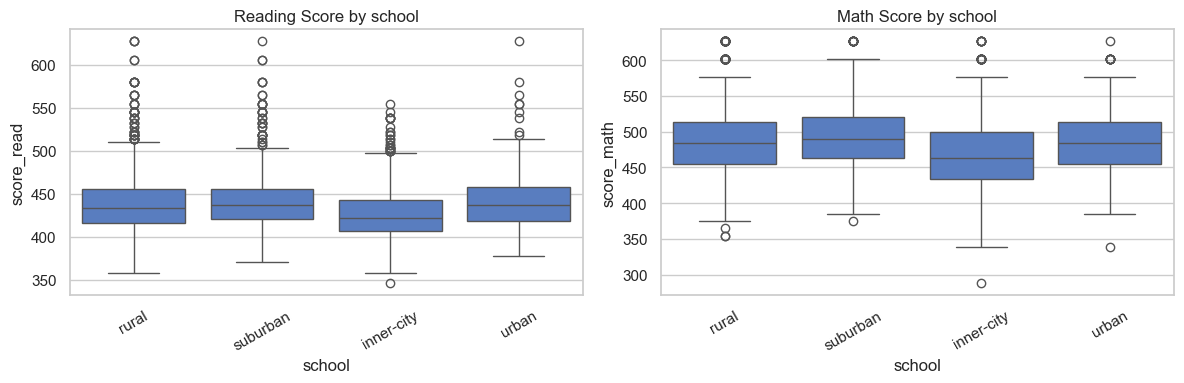

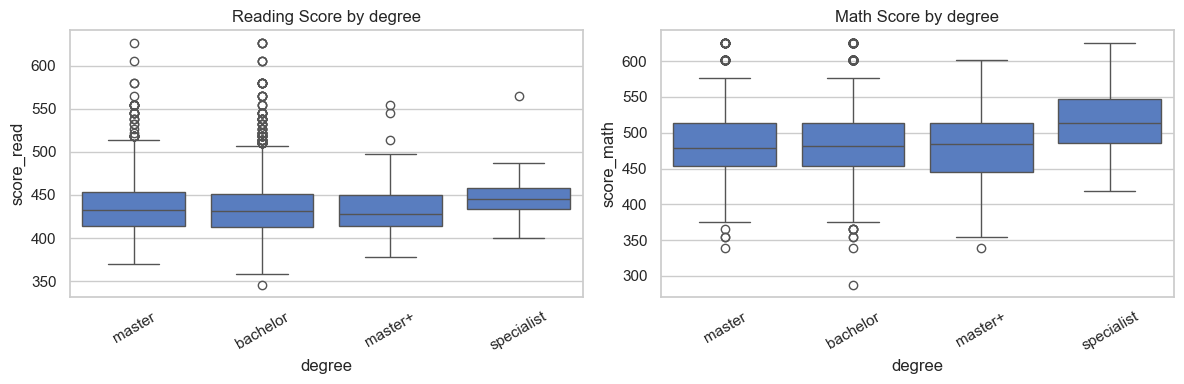

In [6]:
cat_features = ['gender', 'lunch', 'class_type', 'school', 'degree']

for feat in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    sns.boxplot(x=feat, y='score_read', data=df, ax=axes[0])
    axes[0].set_title(f'Reading Score by {feat}')
    axes[0].tick_params(axis='x', rotation=30)

    sns.boxplot(x=feat, y='score_math', data=df, ax=axes[1])
    axes[1].set_title(f'Math Score by {feat}')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

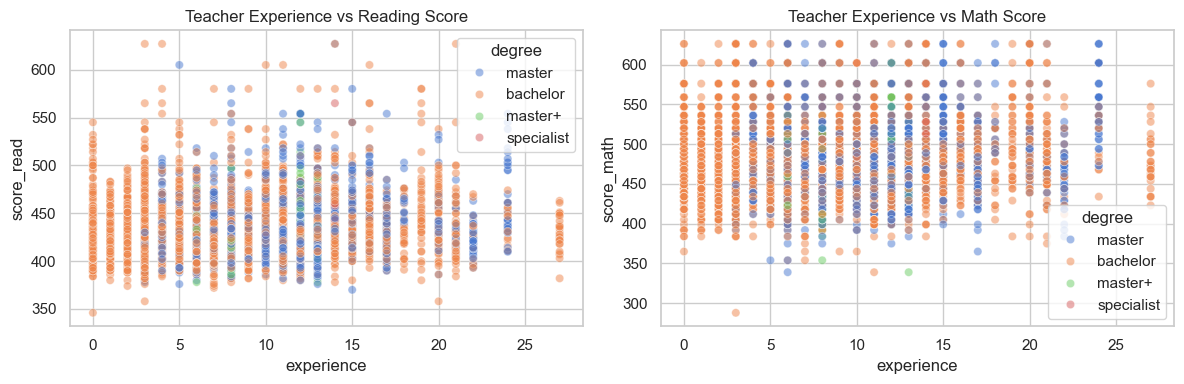

In [7]:
# Teacher experience vs scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='experience', y='score_read', data=df, hue='degree', alpha=0.5, ax=axes[0])
axes[0].set_title('Teacher Experience vs Reading Score')
sns.scatterplot(x='experience', y='score_math', data=df, hue='degree', alpha=0.5, ax=axes[1])
axes[1].set_title('Teacher Experience vs Math Score')
plt.tight_layout()
plt.show()

## 5. Birth-Quarter Cohort Analysis

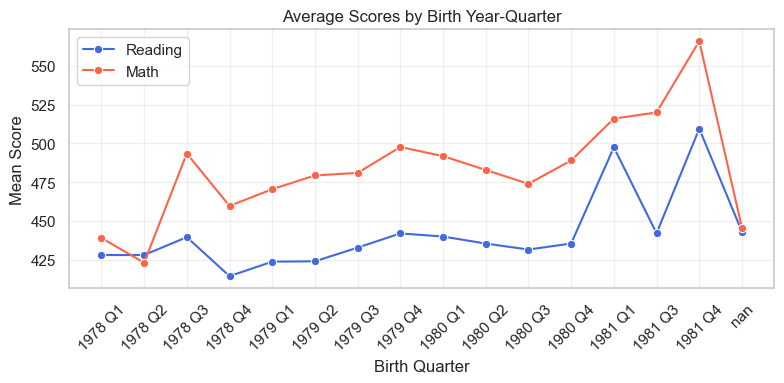

In [8]:
df['birth'] = df['birth'].astype(str)
birth_scores = (
    df.groupby('birth')[['score_read', 'score_math']]
    .mean().reset_index().sort_values('birth')
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=birth_scores, x='birth', y='score_read', marker='o', label='Reading', color='royalblue', ax=ax)
sns.lineplot(data=birth_scores, x='birth', y='score_math', marker='o', label='Math', color='tomato', ax=ax)
ax.set_title('Average Scores by Birth Year-Quarter')
ax.set_xlabel('Birth Quarter')
ax.set_ylabel('Mean Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap (Label Encoded)

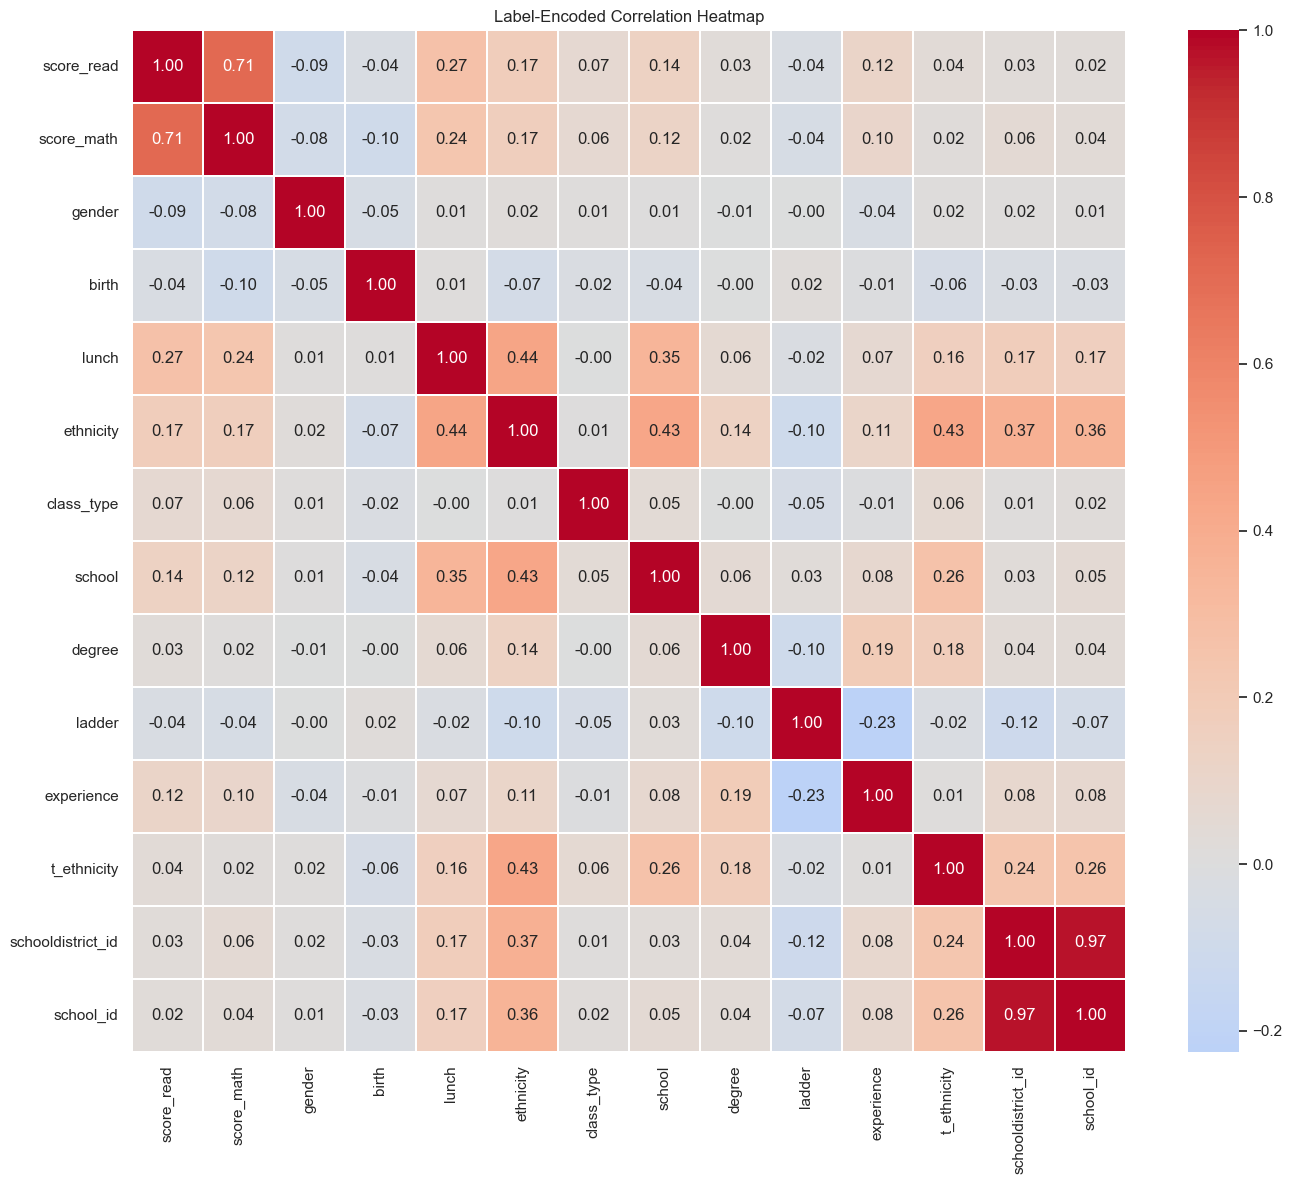

In [9]:
df_label = df.copy()
for col in df_label.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))

corr = df_label.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2, annot=True, fmt='.2f', ax=ax)
ax.set_title('Label-Encoded Correlation Heatmap')
plt.tight_layout()
plt.show()